In [ ]:
import os
import gc
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2, VGG16, ResNet50
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)

print("TensorFlow version:", tf.__version__)
tf.random.set_seed(42)
np.random.seed(42)

gpus = tf.config.list_physical_devices('GPU')
print("GPU available:", bool(gpus), gpus)

# Mixed precision halves activation memory on a Colab T4/A100 GPU with negligible accuracy loss.
if gpus:
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    print("Mixed precision enabled (mixed_float16)")
else:
    print("No GPU detected — training will be slow. Runtime > Change runtime type > GPU.")

TensorFlow version: 2.20.0
GPU available: True [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Mixed precision enabled (mixed_float16)


## Task 1: Dataset Preparation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/DL_Lab_Exp4'
CACHE_RAW = os.path.join(DRIVE_DIR, 'cifar10_raw.npz')      # raw 32x32
CACHE_96  = os.path.join(DRIVE_DIR, 'cifar10_96x96.npz')    # resized 96x96
os.makedirs(DRIVE_DIR, exist_ok=True)

CLASS_NAMES = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

if os.path.exists(CACHE_RAW):
    print('Loading raw CIFAR-10 from Drive cache ...')
    d = np.load(CACHE_RAW)
    X_train, y_train = d['X_train'], d['y_train']
    X_test,  y_test  = d['X_test'],  d['y_test']
else:
    print('Downloading CIFAR-10 ...')
    (X_train, y_train), (X_test, y_test) = cifar10.load_data()
    np.savez_compressed(CACHE_RAW,
                         X_train=X_train, y_train=y_train,
                         X_test=X_test,   y_test=y_test)
    print(f'Saved raw data to {CACHE_RAW}')

print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading raw CIFAR-10 from Drive cache ...
Train: (50000, 32, 32, 3) | Test: (10000, 32, 32, 3)


In [ ]:

# RAM/accuracy sweet spot — far cheaper than the usual 224x224 while still giving the
# convolutional base meaningful spatial resolution to work with)
IMG_SIZE = 96

def resize_in_chunks(images, size=IMG_SIZE, chunk=2000):
    """Resize a uint8 image array in chunks to avoid RAM spikes, returns uint8 array."""
    out = np.empty((len(images), size, size, 3), dtype='uint8')
    for i in range(0, len(images), chunk):
        batch = tf.cast(images[i:i + chunk], tf.float32)
        resized = tf.image.resize(batch, (size, size))
        out[i:i + chunk] = tf.cast(tf.clip_by_value(resized, 0, 255), tf.uint8).numpy()
    return out

if os.path.exists(CACHE_96):
    print('Loading resized 96x96 CIFAR-10 from Drive cache ...')
    d96 = np.load(CACHE_96)
    X_train_96, X_test_96 = d96['X_train'], d96['X_test']
else:
    print('Resizing CIFAR-10 to 96x96 (one-time cost, cached afterwards) ...')
    X_train_96 = resize_in_chunks(X_train)
    X_test_96  = resize_in_chunks(X_test)
    np.savez_compressed(CACHE_96, X_train=X_train_96, X_test=X_test_96)
    print(f'Saved resized data to {CACHE_96}')

print(f'Resized Train: {X_train_96.shape} | Resized Test: {X_test_96.shape}')
print(f'Approx RAM for X_train_96 (uint8): {X_train_96.nbytes / 1e9:.2f} GB')

Loading resized 96x96 CIFAR-10 from Drive cache ...
Resized Train: (50000, 96, 96, 3) | Resized Test: (10000, 96, 96, 3)
Approx RAM for X_train_96 (uint8): 1.38 GB


In [ ]:
y_train_int = y_train.flatten()
y_test_int  = y_test.flatten()
y_train_cat = to_categorical(y_train_int, num_classes=10)
y_test_cat  = to_categorical(y_test_int, num_classes=10)

# Hold out a validation split from training data
VAL_SIZE = 5000
X_val_96,   y_val_cat   = X_train_96[:VAL_SIZE], y_train_cat[:VAL_SIZE]
X_train_fit96, y_train_fit_cat = X_train_96[VAL_SIZE:], y_train_cat[VAL_SIZE:]

print(f"Train: {X_train_fit96.shape} | Val: {X_val_96.shape} | Test: {X_test_96.shape}")

Train: (45000, 96, 96, 3) | Val: (5000, 96, 96, 3) | Test: (10000, 96, 96, 3)


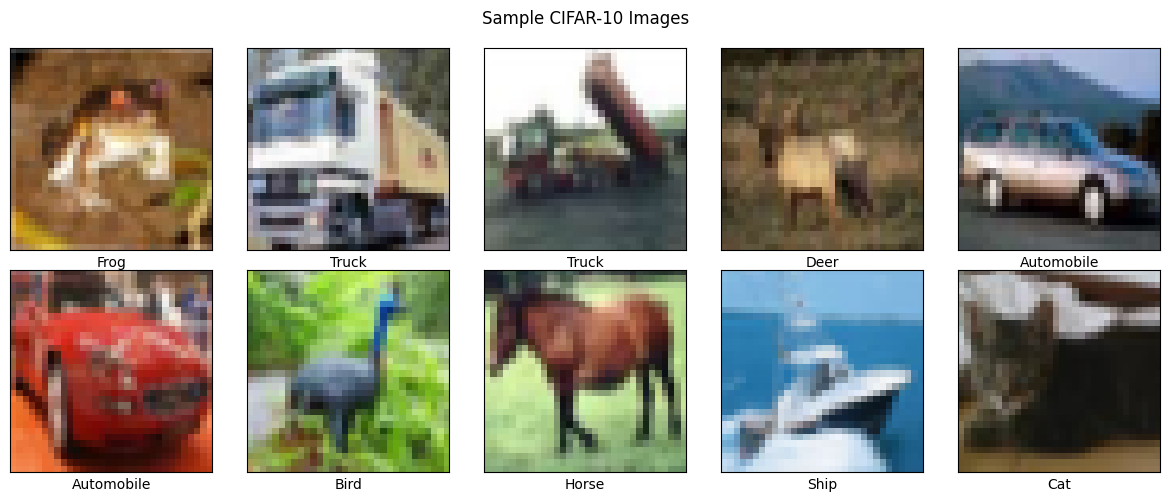


--- Dataset Dimensions ---
Training images : (50000, 32, 32, 3)  labels: (50000, 1)
Testing images   : (10000, 32, 32, 3)  labels: (10000, 1)
Number of classes: 10


In [ ]:
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(X_train[i])  # show native 32x32 for clarity
    plt.xlabel(CLASS_NAMES[y_train_int[i]])
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

print("\n--- Dataset Dimensions ---")
print(f"Training images : {X_train.shape}  labels: {y_train.shape}")
print(f"Testing images   : {X_test.shape}  labels: {y_test.shape}")
print(f"Number of classes: {len(CLASS_NAMES)}")

In [ ]:
# Normalization and augmentation happen per-batch inside the pipeline — the raw uint8
# arrays in RAM/Drive are never blown up into float32 copies of the whole dataset.
AUTOTUNE = tf.data.AUTOTUNE
BATCH_SIZE = 32

def make_dataset(X, y, batch_size=BATCH_SIZE, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=min(4096, len(X)), seed=42)

    def _prep(img, label):
        img = tf.cast(img, tf.float32) / 255.0
        if augment:
            img = tf.image.random_flip_left_right(img)
        return img, label

    ds = ds.map(_prep, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(X_train_fit96, y_train_fit_cat, shuffle=True, augment=True)
val_ds   = make_dataset(X_val_96, y_val_cat)
test_ds  = make_dataset(X_test_96, y_test_cat)

## Task 2: Transfer Learning — Build the Model (MobileNetV2 backbone)

In [ ]:
def build_transfer_model(base_name='mobilenet', dense_units=128, input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    """Loads a pretrained ImageNet backbone, freezes it, and attaches a new classifier head."""
    if base_name == 'mobilenet':
        base = MobileNetV2(include_top=False, weights='imagenet', input_shape=input_shape)
    elif base_name == 'vgg16':
        base = VGG16(include_top=False, weights='imagenet', input_shape=input_shape)
    elif base_name == 'resnet50':
        base = ResNet50(include_top=False, weights='imagenet', input_shape=input_shape)
    else:
        raise ValueError(f"Unknown base_name: {base_name}")

    base.trainable = False  # freeze the convolutional base

    inputs = tf.keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(dense_units, activation='relu', name='dense_head')(x)
    x = layers.Dropout(0.3, name='dropout_head')(x)
    outputs = layers.Dense(10, activation='softmax', dtype='float32', name='predictions')(x)

    model = models.Model(inputs, outputs, name=f'{base_name}_transfer')
    return model, base

model, base_model = build_transfer_model('mobilenet', dense_units=128)
model.summary()

trainable = sum(np.prod(v.shape) for v in model.trainable_variables)
total = model.count_params()
print(f"\nTotal parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}  (frozen base = {total - trainable:,})")

Model: "mobilenet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_head (Dense)              │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_head (Dropout)          │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Total parameters:     2,423,242
Trainable parameters: 165,258  (frozen base = 2,257,984)


## Task 3: Model Training

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

CKPT_PATH = os.path.join(DRIVE_DIR, 'mobilenet_transfer_best.keras')
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint(CKPT_PATH, monitor='val_accuracy', save_best_only=True),
]

EPOCHS_HEAD = 10  # per spec's 10-20 range; kept at the low end for Colab session limits

start = time.time()
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_HEAD, callbacks=callbacks)
head_train_time = time.time() - start
print(f"\nHead-training time: {head_train_time:.1f} sec")

pre_finetune_test_loss, pre_finetune_test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy BEFORE fine-tuning: {pre_finetune_test_acc:.4f}")

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 115s 53ms/step - accuracy: 0.7102 - loss: 0.8398 - val_accuracy: 0.7870 - val_loss: 0.6076
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7697 - loss: 0.6636 - val_accuracy: 0.7964 - val_loss: 0.5808
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7869 - loss: 0.6132 - val_accuracy: 0.8080 - val_loss: 0.5487
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7958 - loss: 0.5841 - val_accuracy: 0.8056 - val_loss: 0.5498
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8035 - loss: 0.5543 - val_accuracy: 0.8178 - val_loss: 0.5437
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.8117 - loss: 0.5344 - val_accuracy: 0.8100 - val_loss: 0.5462
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8191 - loss: 0.5148 - val_accuracy: 0.8142 - val_loss: 0.5404
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.8227 - lo

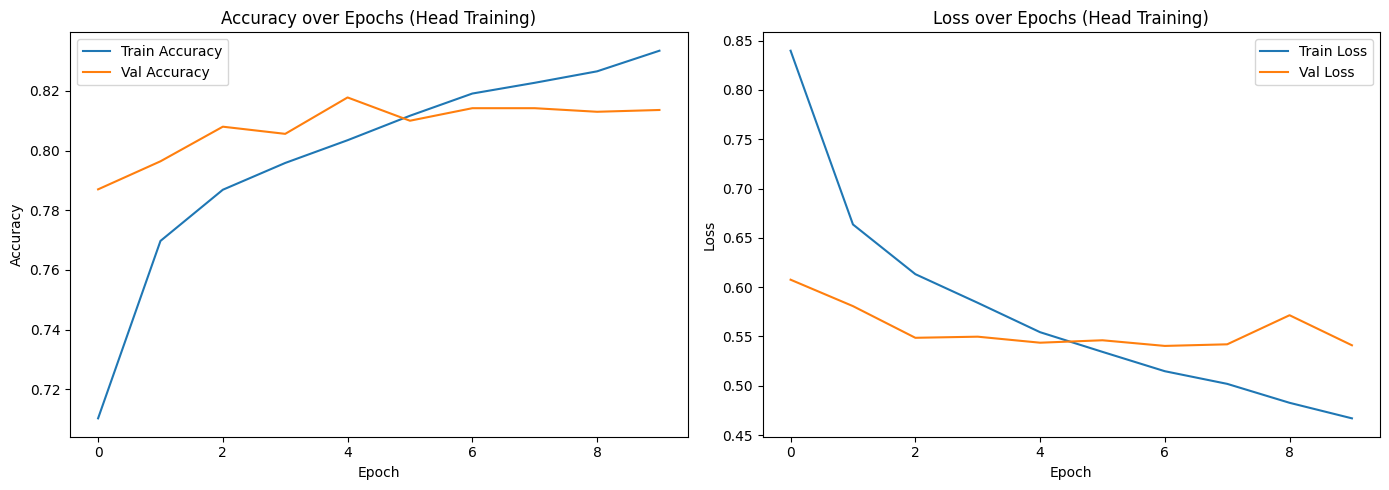

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs (Head Training)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs (Head Training)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout()
plt.show()

## Task 4: Fine-Tuning

In [ ]:
UNFREEZE_LAST_N = 20  # unfreezes roughly the "last convolutional block" worth of layers

base_model.trainable = True
for layer in base_model.layers[:-UNFREEZE_LAST_N]:
    layer.trainable = False

trainable_after = sum(np.prod(v.shape) for v in model.trainable_variables)
print(f"Trainable parameters after unfreezing: {trainable_after:,} "
      f"(was {trainable:,} during head-only training)")

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),  # small LR to avoid destroying pretrained weights
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS_FT = 6  # per spec's 5-10 range

start = time.time()
history_ft = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FT, callbacks=callbacks)
finetune_time = time.time() - start
print(f"\nFine-tuning time: {finetune_time:.1f} sec")

post_finetune_test_loss, post_finetune_test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy AFTER fine-tuning: {post_finetune_test_acc:.4f}")

print("\n--- Accuracy Before vs After Fine-Tuning ---")
print(f"Before: {pre_finetune_test_acc:.4f}")
print(f"After:  {post_finetune_test_acc:.4f}")
print(f"Change: {post_finetune_test_acc - pre_finetune_test_acc:+.4f}")

Trainable parameters after unfreezing: 1,371,338 (was 165,258 during head-only training)
Epoch 1/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 93s 46ms/step - accuracy: 0.6791 - loss: 1.1836 - val_accuracy: 0.7998 - val_loss: 0.6339
Epoch 2/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.7541 - loss: 0.7605 - val_accuracy: 0.8030 - val_loss: 0.6037
Epoch 3/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.7812 - loss: 0.6504 - val_accuracy: 0.8108 - val_loss: 0.5627
Epoch 4/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.8016 - loss: 0.5767 - val_accuracy: 0.8230 - val_loss: 0.5349
Epoch 5/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.8198 - loss: 0.5225 - val_accuracy: 0.8318 - val_loss: 0.5148
Epoch 6/6
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.8315 - loss: 0.4865 - val_accuracy: 0.8400 - val_loss: 0.4941

Fine-tuning time: 179.0 sec
Test accuracy AFTER fine-tuning: 0.8324

--- Accuracy Before vs After Fine-Tuning ---
Before: 0.

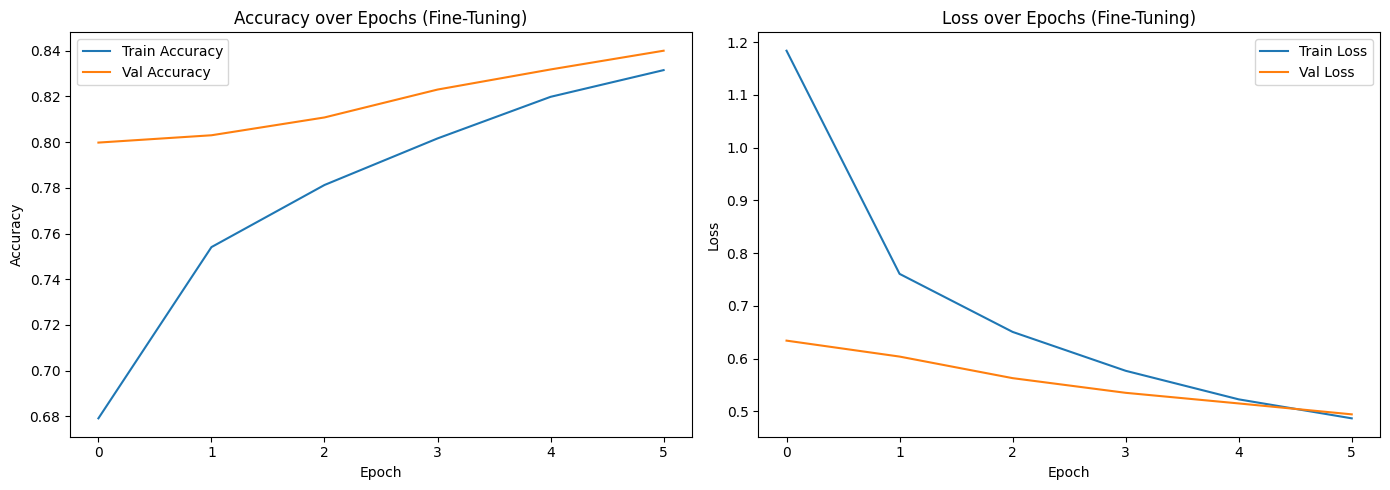

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_ft.history['accuracy'], label='Train Accuracy')
axes[0].plot(history_ft.history['val_accuracy'], label='Val Accuracy')
axes[0].set_title('Accuracy over Epochs (Fine-Tuning)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].legend()

axes[1].plot(history_ft.history['loss'], label='Train Loss')
axes[1].plot(history_ft.history['val_loss'], label='Val Loss')
axes[1].set_title('Loss over Epochs (Fine-Tuning)')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].legend()
plt.tight_layout()
plt.show()

## Task 5: Model Evaluation

313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 56ms/step
Accuracy:  0.8324
Precision: 0.8319
Recall:    0.8324
F1-score:  0.8318

Classification Report:

              precision    recall  f1-score   support

    Airplane       0.84      0.85      0.85      1000
  Automobile       0.89      0.92      0.91      1000
        Bird       0.79      0.78      0.79      1000
         Cat       0.71      0.71      0.71      1000
        Deer       0.80      0.78      0.79      1000
         Dog       0.78      0.73      0.76      1000
        Frog       0.82      0.90      0.86      1000
       Horse       0.86      0.85      0.86      1000
        Ship       0.91      0.91      0.91      1000
       Truck       0.90      0.90      0.90      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



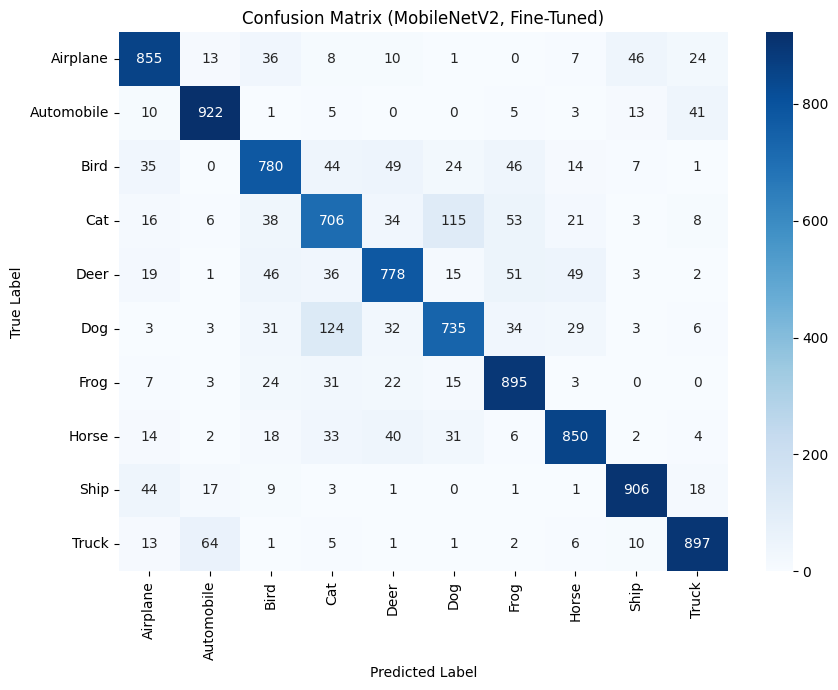

In [ ]:
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_int

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='macro')
rec  = recall_score(y_true, y_pred, average='macro')
f1   = f1_score(y_true, y_pred, average='macro')

print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# Confusion matrix (mandatory plot #6)
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix (MobileNetV2, Fine-Tuned)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

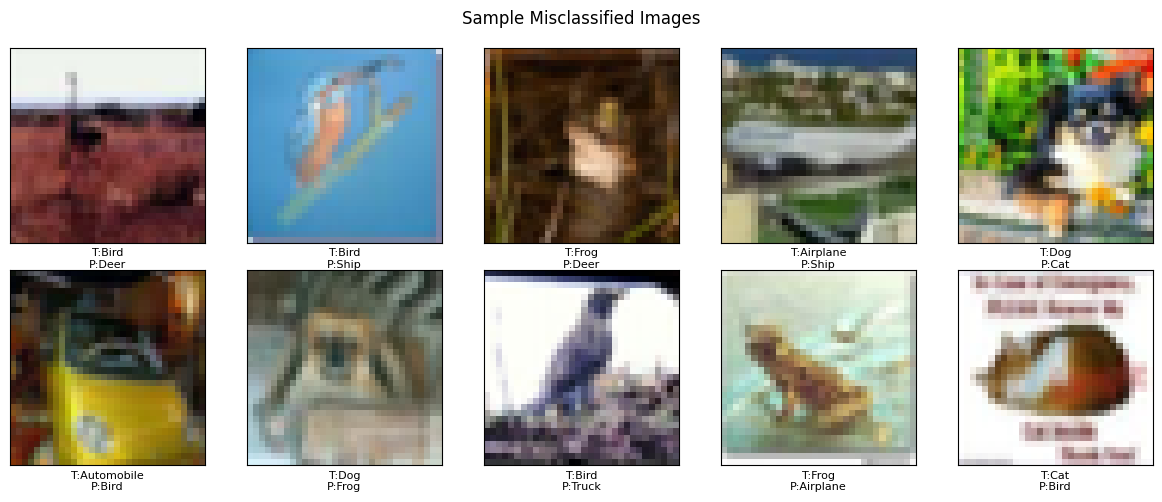

In [ ]:
mis_idx = np.where(y_pred != y_true)[0]
show_n = min(10, len(mis_idx))
sample_mis = np.random.choice(mis_idx, show_n, replace=False)

plt.figure(figsize=(12, 5))
for i, idx in enumerate(sample_mis):
    plt.subplot(2, 5, i + 1)
    plt.xticks([]); plt.yticks([]); plt.grid(False)
    plt.imshow(X_test[idx])  # native resolution for clarity
    plt.xlabel(f"T:{CLASS_NAMES[y_true[idx]]}\nP:{CLASS_NAMES[y_pred[idx]]}", fontsize=8)
plt.suptitle("Sample Misclassified Images")
plt.tight_layout()
plt.show()

In [ ]:
SUBSET_TRAIN = 6000
SUBSET_TEST  = 1500
HP_EPOCHS = 3

rng = np.random.default_rng(42)
sub_idx_train = rng.choice(len(X_train_fit96), SUBSET_TRAIN, replace=False)
sub_idx_test  = rng.choice(len(X_test_96), SUBSET_TEST, replace=False)

X_sub_train, y_sub_train = X_train_fit96[sub_idx_train], y_train_fit_cat[sub_idx_train]
X_sub_test,  y_sub_test  = X_test_96[sub_idx_test],  y_test_cat[sub_idx_test]

def run_hp_experiment(optimizer_name='adam', lr=0.001, batch_size=32,
                       dense_units=128, frozen='all', epochs=HP_EPOCHS):
    tf.keras.backend.clear_session()
    m, base = build_transfer_model('mobilenet', dense_units=dense_units)

    if frozen == 'partial':
        base.trainable = True
        for layer in base.layers[:-10]:
            layer.trainable = False
    # 'all' leaves base.trainable = False from build_transfer_model()

    opt = optimizers.Adam(learning_rate=lr) if optimizer_name == 'adam' \
        else optimizers.SGD(learning_rate=lr, momentum=0.9)
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    tr_ds = make_dataset(X_sub_train, y_sub_train, batch_size=batch_size, shuffle=True)
    te_ds = make_dataset(X_sub_test, y_sub_test, batch_size=batch_size)

    t0 = time.time()
    m.fit(tr_ds, epochs=epochs, verbose=0)
    elapsed = time.time() - t0
    _, test_acc = m.evaluate(te_ds, verbose=0)

    del m, base
    gc.collect()
    return test_acc, elapsed

hp_configs = [
    {'optimizer_name': 'adam', 'lr': 0.001,  'batch_size': 32, 'frozen': 'all'},
    {'optimizer_name': 'adam', 'lr': 0.0001, 'batch_size': 32, 'frozen': 'all'},
    {'optimizer_name': 'sgd',  'lr': 0.001,  'batch_size': 32, 'frozen': 'all'},
    {'optimizer_name': 'adam', 'lr': 0.001,  'batch_size': 64, 'frozen': 'all'},
    {'optimizer_name': 'adam', 'lr': 0.001,  'batch_size': 32, 'frozen': 'partial'},
]

hp_results = []
for cfg in hp_configs:
    test_acc, elapsed = run_hp_experiment(**cfg)
    hp_results.append({**cfg, 'test_accuracy': round(test_acc, 4), 'time_sec': round(elapsed, 1)})
    print(cfg, "-> acc:", round(test_acc, 4), " time:", round(elapsed, 1), "s")

hp_df = pd.DataFrame(hp_results)
print("\nHyperparameter Study Summary:")
print(hp_df.to_string(index=False))

{'optimizer_name': 'adam', 'lr': 0.001, 'batch_size': 32, 'frozen': 'all'} -> acc: 0.7407  time: 34.4 s
{'optimizer_name': 'adam', 'lr': 0.0001, 'batch_size': 32, 'frozen': 'all'} -> acc: 0.698  time: 17.9 s
{'optimizer_name': 'sgd', 'lr': 0.001, 'batch_size': 32, 'frozen': 'all'} -> acc: 0.7113  time: 17.6 s
{'optimizer_name': 'adam', 'lr': 0.001, 'batch_size': 64, 'frozen': 'all'} -> acc: 0.7353  time: 31.8 s
{'optimizer_name': 'adam', 'lr': 0.001, 'batch_size': 32, 'frozen': 'partial'} -> acc: 0.632  time: 24.9 s

Hyperparameter Study Summary:
optimizer_name     lr  batch_size  frozen  test_accuracy  time_sec
          adam 0.0010          32     all         0.7407      34.4
          adam 0.0001          32     all         0.6980      17.9
           sgd 0.0010          32     all         0.7113      17.6
          adam 0.0010          64     all         0.7353      31.8
          adam 0.0010          32 partial         0.6320      24.9


In [ ]:
def build_lenet5(input_shape=(32, 32, 3), num_classes=10):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(6, (5, 5), activation='tanh', padding='same'),
        layers.AveragePooling2D((2, 2)),
        layers.Conv2D(16, (5, 5), activation='tanh'),
        layers.AveragePooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(num_classes, activation='softmax', dtype='float32'),
    ], name='LeNet5')

In [ ]:
def build_alexnet_lite(input_shape=(32, 32, 3), num_classes=10):
    return models.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax', dtype='float32'),
    ], name='AlexNetLite')

In [ ]:
# sub_idx_train/sub_idx_test index into X_train_fit96 / X_test_96, which preserve the same
# row order as X_train[VAL_SIZE:] / X_test — so the same indices select the matching
# native-resolution images.
X_sub_train_32 = X_train[VAL_SIZE:][sub_idx_train]
y_sub_train_32 = y_train_cat[VAL_SIZE:][sub_idx_train]
X_sub_test_32  = X_test[sub_idx_test]
y_sub_test_32  = y_test_cat[sub_idx_test]

def run_scratch_model(build_fn, name, epochs=HP_EPOCHS, batch_size=32):
    tf.keras.backend.clear_session()
    m = build_fn()
    m.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])
    tr_ds = make_dataset(X_sub_train_32, y_sub_train_32, batch_size=batch_size, shuffle=True)
    te_ds = make_dataset(X_sub_test_32, y_sub_test_32, batch_size=batch_size)

    total_params = m.count_params()
    t0 = time.time()
    m.fit(tr_ds, epochs=epochs, verbose=0)
    elapsed = time.time() - t0
    _, test_acc = m.evaluate(te_ds, verbose=0)

    del m
    gc.collect()
    return {'Architecture': name, 'Parameters': total_params,
            'Accuracy (%)': round(test_acc * 100, 2), 'Training Time (s)': round(elapsed, 1)}

comparison_rows = []
comparison_rows.append(run_scratch_model(build_lenet5, 'LeNet-5'))
comparison_rows.append(run_scratch_model(build_alexnet_lite, 'AlexNet (lite)'))

In [ ]:
for base_name, label in [('vgg16', 'VGG16'), ('resnet50', 'ResNet50'), ('mobilenet', 'MobileNetV2')]:
    tf.keras.backend.clear_session()
    m, base = build_transfer_model(base_name, dense_units=128)
    m.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])

    tr_ds = make_dataset(X_sub_train, y_sub_train, batch_size=32, shuffle=True)
    te_ds = make_dataset(X_sub_test, y_sub_test, batch_size=32)

    total_params = m.count_params()
    t0 = time.time()
    m.fit(tr_ds, epochs=HP_EPOCHS, verbose=0)
    elapsed = time.time() - t0
    _, test_acc = m.evaluate(te_ds, verbose=0)

    comparison_rows.append({'Architecture': label, 'Parameters': total_params,
                             'Accuracy (%)': round(test_acc * 100, 2),
                             'Training Time (s)': round(elapsed, 1)})
    print(f"{label}: params={total_params:,}  acc={test_acc:.4f}  time={elapsed:.1f}s")

    del m, base
    gc.collect()

VGG16: params=14,781,642  acc=0.5780  time=31.5s
ResNet50: params=23,851,274  acc=0.2087  time=28.7s
MobileNetV2: params=2,423,242  acc=0.7293  time=17.7s


In [ ]:
comparison_df = pd.DataFrame(comparison_rows)
print("\n=== Architecture Comparison (subset-trained, for relative comparison only) ===")
print(comparison_df.to_string(index=False))

comparison_df.to_csv(os.path.join(DRIVE_DIR, 'architecture_comparison.csv'), index=False)
print(f"\nSaved comparison table to {os.path.join(DRIVE_DIR, 'architecture_comparison.csv')}")


=== Architecture Comparison (subset-trained, for relative comparison only) ===
  Architecture  Parameters  Accuracy (%)  Training Time (s)
       LeNet-5       83126         36.93                7.9
AlexNet (lite)      833738         35.73               11.7
         VGG16    14781642         57.80               31.5
      ResNet50    23851274         20.87               28.7
   MobileNetV2     2423242         72.93               17.7

Saved comparison table to /content/drive/MyDrive/DL_Lab_Exp4/architecture_comparison.csv


## Section 18.1: Final Performance Metrics Summary (MobileNetV2, primary model)

In [ ]:
summary = pd.DataFrame([{
    'Training Accuracy (final epoch)': round(history_ft.history['accuracy'][-1], 4),
    'Testing Accuracy': round(post_finetune_test_acc, 4),
    'Precision': round(prec, 4),
    'Recall': round(rec, 4),
    'F1-score': round(f1, 4),
    'Head-Training Time (s)': round(head_train_time, 1),
    'Fine-Tuning Time (s)': round(finetune_time, 1),
    'Total Parameters': model.count_params(),
}]).T
summary.columns = ['Value']
print(summary)
summary.to_csv(os.path.join(DRIVE_DIR, 'final_metrics_summary.csv'))

                                        Value
Training Accuracy (final epoch)  8.315000e-01
Testing Accuracy                 8.324000e-01
Precision                        8.319000e-01
Recall                           8.324000e-01
F1-score                         8.318000e-01
Head-Training Time (s)           2.504000e+02
Fine-Tuning Time (s)             1.790000e+02
Total Parameters                 2.423242e+06


## Cleanup
Frees GPU/CPU memory at the end of the session — useful if you plan to keep experimenting
in the same Colab runtime afterwards.

In [ ]:
tf.keras.backend.clear_session()
gc.collect()
print("Session cleared. Cached files remain on Drive for reuse in future sessions:")
print(f"  {CACHE_RAW}")
print(f"  {CACHE_96}")
print(f"  {CKPT_PATH}")